### TASK 1: Data Immersion & Wrangling

### Importing Required Libraries

import the necessary Python libraries for data analysis and visualization.  
- **Pandas** is used for data manipulation and analysis  
- **NumPy** supports numerical operations  
- **Matplotlib** is used for basic data visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Data Loading

The dataset is loaded into a Pandas DataFrame for analysis.  
Initial inspection of the dataset helps understand its structure, including the number of rows and columns.

In [2]:
# Load dataset
df = pd.read_csv("/Users/saniyacarvalho/Desktop/train.csv")
print("Shape:", df.shape)
df.head()

Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


### Standardizing Column Names

Column names are cleaned by removing extra spaces and converting them to lowercase.  
This ensures consistency and prevents errors during data processing.

In [3]:
df.columns = df.columns.str.strip().str.lower()

print(df.columns)

Index(['row id', 'order id', 'order date', 'ship date', 'ship mode',
       'customer id', 'customer name', 'segment', 'country', 'city', 'state',
       'postal code', 'region', 'product id', 'category', 'sub-category',
       'product name', 'sales'],
      dtype='object')


### Data Exploration

In this step, we explore the dataset structure and summary statistics.  
- `.info()` provides data types and non-null counts  
- `.describe()` gives statistical summaries for numerical columns  

This helps identify potential data quality issues early.

In [4]:
# Check data types
df.info()
# Statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row id         9800 non-null   int64  
 1   order id       9800 non-null   object 
 2   order date     9800 non-null   object 
 3   ship date      9800 non-null   object 
 4   ship mode      9800 non-null   object 
 5   customer id    9800 non-null   object 
 6   customer name  9800 non-null   object 
 7   segment        9800 non-null   object 
 8   country        9800 non-null   object 
 9   city           9800 non-null   object 
 10  state          9800 non-null   object 
 11  postal code    9789 non-null   float64
 12  region         9800 non-null   object 
 13  product id     9800 non-null   object 
 14  category       9800 non-null   object 
 15  sub-category   9800 non-null   object 
 16  product name   9800 non-null   object 
 17  sales          9800 non-null   float64
dtypes: float

,row id,postal code,sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


### Data Dictionary Creation

A data dictionary is created to document each variable in the dataset.  
It includes:
- Column names  
- Data types  
- Descriptions  
- Business relevance  

This step ensures clarity and aligns technical data with business understanding.

In [5]:
data_dict = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.notnull().sum().values,
    "Unique Values": df.nunique().values
})

descriptions = {
    "row id": "Unique row identifier",
    "order id": "Unique identifier for each order",
    "order date": "Date when the order was placed",
    "ship date": "Date when the order was shipped",
    "ship mode": "Shipping method used",
    "customer id": "Unique customer identifier",
    "customer name": "Name of the customer",
    "segment": "Customer segment classification",
    "country": "Customer country",
    "city": "Customer city",
    "state": "Customer state",
    "postal code": "Postal code of the region",
    "region": "Geographical region",
    "product id": "Unique product identifier",
    "category": "Main product category",
    "sub-category": "Sub classification of product",
    "product name": "Name of the product",
    "sales": "Revenue generated",

    # Engineered Features
    "order year": "Year extracted from order date",
    "order month": "Month extracted from order date",
    "order day": "Day extracted from order date",
    "order weekday": "Day of week of order",
    "shipping days": "Number of days taken for delivery"
}

business_use = {
    "order date": "Used for trend analysis",
    "ship date": "Used to evaluate delivery timelines",
    "region": "Used for regional performance comparison",
    "category": "Used for category-level analysis",
    "sales": "Key performance metric for revenue",

    # Engineered Features
    "order year": "Used for yearly trend analysis",
    "order month": "Used for seasonal trend analysis",
    "order weekday": "Used for weekday vs weekend patterns",
    "shipping days": "Used to evaluate delivery efficiency"
}

data_dict["Description"] = data_dict["Column Name"].map(descriptions)
data_dict["Business Relevance"] = data_dict["Column Name"].map(business_use)

data_dict.fillna("Not Defined", inplace=True)

data_dict

,Column Name,Data Type,Non-Null Count,Unique Values,Description,Business Relevance
0,row id,int64,9800,9800,Unique row identifier,Not Defined
1,order id,object,9800,4922,Unique identifier for each order,Not Defined
2,order date,object,9800,1230,Date when the order was placed,Used for trend analysis
3,ship date,object,9800,1326,Date when the order was shipped,Used to evaluate delivery timelines
4,ship mode,object,9800,4,Shipping method used,Not Defined
5,customer id,object,9800,793,Unique customer identifier,Not Defined
6,customer name,object,9800,793,Name of the customer,Not Defined
7,segment,object,9800,3,Customer segment classification,Not Defined
8,country,object,9800,1,Customer country,Not Defined
9,city,object,9800,529,Customer city,Not Defined


### Data Quality Assessment

The dataset is checked for common data issues such as:
- Missing values  
- Duplicate records  

Identifying these issues is critical before performing any analysis.

In [6]:
# Missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 row id            0
order id          0
order date        0
ship date         0
ship mode         0
customer id       0
customer name     0
segment           0
country           0
city              0
state             0
postal code      11
region            0
product id        0
category          0
sub-category      0
product name      0
sales             0
dtype: int64


In [7]:
# Duplicates
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


**Data Cleaning**

In [8]:
print(df.columns)

Index(['row id', 'order id', 'order date', 'ship date', 'ship mode',
       'customer id', 'customer name', 'segment', 'country', 'city', 'state',
       'postal code', 'region', 'product id', 'category', 'sub-category',
       'product name', 'sales'],
      dtype='object')


In [9]:
df.columns = df.columns.str.strip().str.lower()

### Data Cleaning

In this step, data inconsistencies are handled:
- Date columns are converted to proper datetime format  
- Duplicate rows are removed  
- Missing values are handled appropriately  

This ensures the dataset is accurate and reliable for analysis.

In [10]:
df['order date'] = pd.to_datetime(df['order date'], errors='coerce')
df['ship date'] = pd.to_datetime(df['ship date'], errors='coerce')

df.drop_duplicates(inplace=True)

df.fillna(method='ffill', inplace=True)

/var/folders/6h/r6sy20ds74xc3zx5xx137xb40000gn/T/ipykernel_4046/424411632.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [11]:
print(df.columns)

Index(['row id', 'order id', 'order date', 'ship date', 'ship mode',
       'customer id', 'customer name', 'segment', 'country', 'city', 'state',
       'postal code', 'region', 'product id', 'category', 'sub-category',
       'product name', 'sales'],
      dtype='object')


### Feature Engineering

New features are created from existing data to enhance analysis:
- Time-based features (year, month, day, weekday)  
- Shipping duration calculated from order and ship dates  

These features help uncover trends and improve business insights.

In [12]:
df['order year'] = df['order date'].dt.year
df['order month'] = df['order date'].dt.month
df['order day'] = df['order date'].dt.day
df['order weekday'] = df['order date'].dt.day_name()

df['shipping days'] = (df['ship date'] - df['order date']).dt.days

### Outlier Detection

Outliers in the sales data are identified using:
- Boxplot visualization  
- Interquartile Range (IQR) method  

Detecting outliers helps understand extreme values and ensures robust analysis.

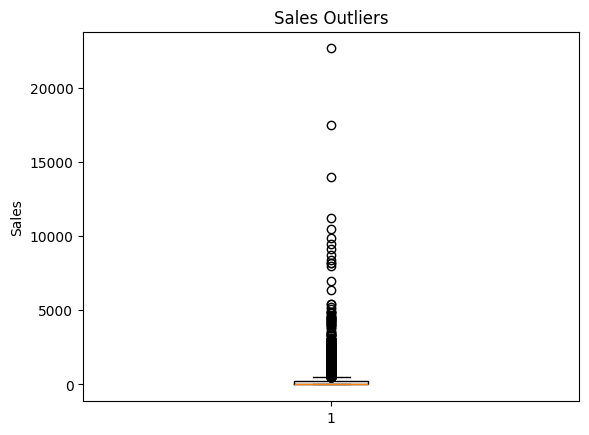

Number of outliers: 1145


In [13]:
plt.figure()
plt.boxplot(df['sales'])
plt.title("Sales Outliers")
plt.ylabel("Sales")
plt.show()

Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['sales'] < Q1 - 1.5 * IQR) |
              (df['sales'] > Q3 + 1.5 * IQR)]

print("Number of outliers:", len(outliers))

### Saving Cleaned Dataset

The final cleaned and transformed dataset is saved as a CSV file.  
This dataset is now ready for further analysis such as EDA and dashboarding.

In [14]:
print("Final Shape:", df.shape)

df.to_csv("cleaned_superstore_data.csv", index=False)

Final Shape: (9800, 23)


### Conclusion

The dataset was successfully cleaned and transformed into an analysis-ready format.  
Data quality issues such as missing values and duplicates were handled effectively.  
Feature engineering enhanced the dataset by introducing time-based insights and delivery performance metrics.  
This prepared dataset will be used for further exploratory data analysis and business intelligence tasks.

### TASK 2: Exploratory Data Analysis & Business Intelligence

### Exploratory Data Analysis (EDA)

In this task, we analyze the cleaned dataset to uncover patterns, trends, and relationships.  
The goal is to generate actionable business insights using statistical analysis and visualization.

### Loading Clean Dataset

We load the cleaned dataset prepared in Task 1 for further analysis.

In [15]:
df = pd.read_csv("cleaned_superstore_data.csv")

df.head()

,row id,order id,order date,ship date,ship mode,customer id,customer name,segment,country,city,...,product id,category,sub-category,product name,sales,order year,order month,order day,order weekday,shipping days
0,1,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,8,11,Friday,92
1,2,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,8,11,Friday,92
2,3,CA-2017-138688,2017-12-06,2017-11-11,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,12,6,Wednesday,-25
3,4,US-2016-108966,2016-11-10,2017-11-11,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,11,10,Thursday,366
4,5,US-2016-108966,2016-11-10,2017-11-11,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,11,10,Thursday,366


### Descriptive Statistics

We calculate summary statistics to understand the distribution of numerical variables such as sales.

In [16]:
df.describe()

,row id,postal code,sales,order year,order month,order day,shipping days
count,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000
mean,4900.500000,55295.655714,230.769059,2016.758878,6.530102,7.963776,11.728776
std,2829.160653,32035.893637,626.651875,1.116594,3.503779,3.262070,419.355291
min,1.000000,1040.000000,0.444000,2015.000000,1.000000,1.000000,-1427.000000
25%,2450.750000,23223.000000,17.248000,2016.000000,3.000000,5.000000,-100.000000
50%,4900.500000,59253.500000,54.490000,2017.000000,7.000000,9.000000,92.000000
75%,7350.250000,90008.000000,210.605000,2018.000000,10.000000,11.000000,153.000000
max,9800.000000,99301.000000,22638.480000,2018.000000,12.000000,12.000000,1488.000000


### Univariate Analysis

### Sales Distribution

This visualization helps understand how sales values are distributed and identify skewness or concentration.

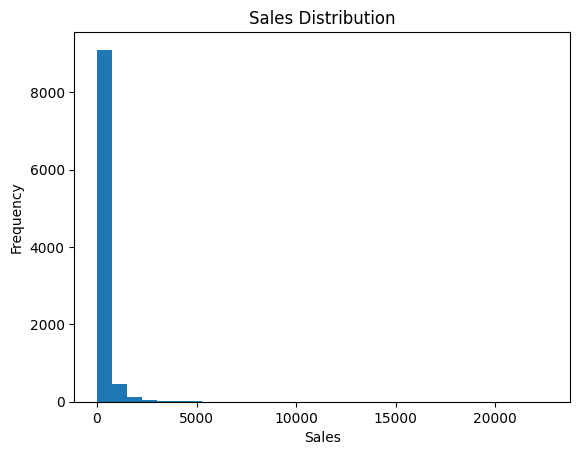

In [17]:
import matplotlib.pyplot as plt

plt.hist(df['sales'], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

**Insight:**

Sales are typically right-skewed, indicating that a small number of transactions contribute disproportionately high revenue.

### Sales by Category

This analysis identifies which product categories contribute most to total revenue.

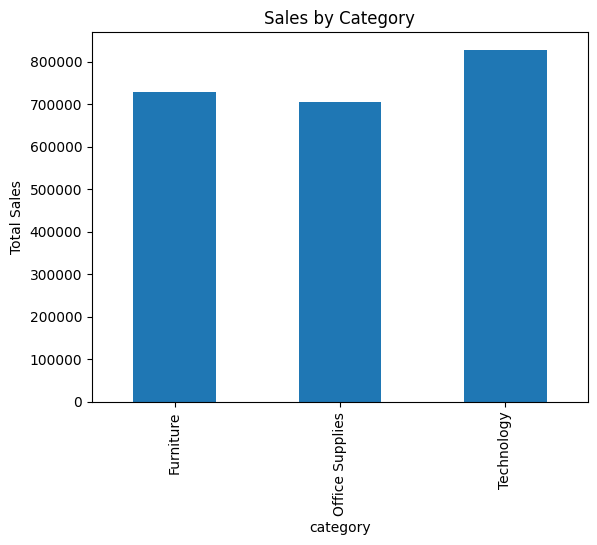

In [18]:
df.groupby('category')['sales'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.ylabel("Total Sales")
plt.show()

**Insight:**

Certain categories dominate revenue contribution, suggesting areas for focused marketing and inventory optimization.

### Monthly Sales Trend

This line chart shows how sales vary across months, helping identify seasonal trends.

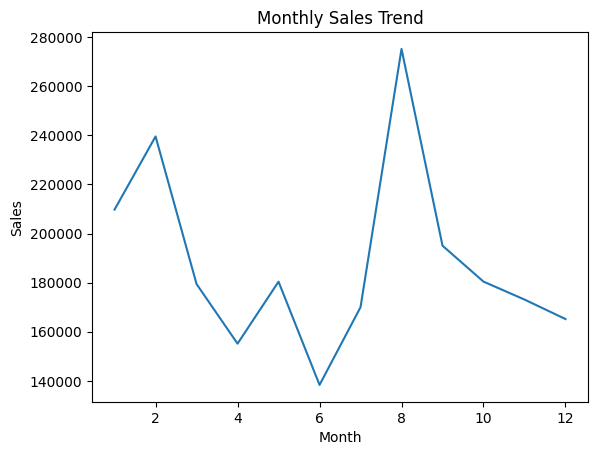

In [19]:
monthly_sales = df.groupby('order month')['sales'].sum()

plt.plot(monthly_sales)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

**Insight:**

Peaks and dips indicate seasonality, which can guide promotional campaigns.

### Sales by Region

This visualization compares sales across regions.

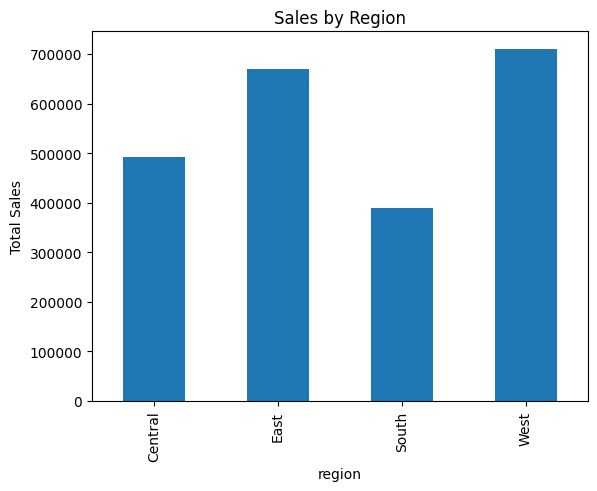

In [20]:
df.groupby('region')['sales'].sum().plot(kind='bar')
plt.title("Sales by Region")
plt.ylabel("Total Sales")
plt.show()

**Insight:**

Top-performing regions contribute disproportionately to revenue.

### Sales vs Shipping Time

This scatter plot evaluates whether delivery speed impacts sales.

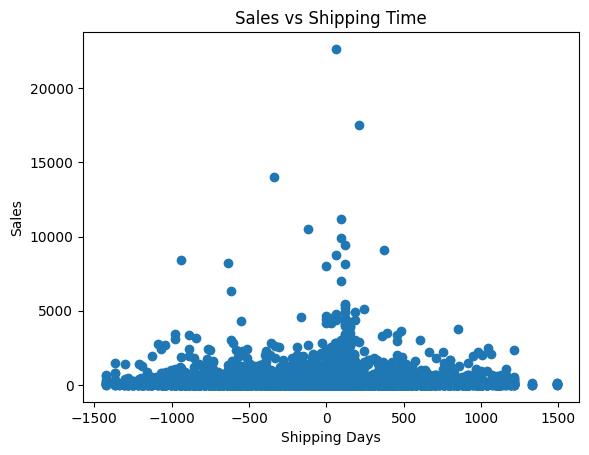

In [21]:
plt.scatter(df['shipping days'], df['sales'])
plt.xlabel("Shipping Days")
plt.ylabel("Sales")
plt.title("Sales vs Shipping Time")
plt.show()

**Insight:**

Weak relationship suggests that faster shipping alone does not directly increase sales.

### Correlation Heatmap

This heatmap shows relationships between numerical variables.

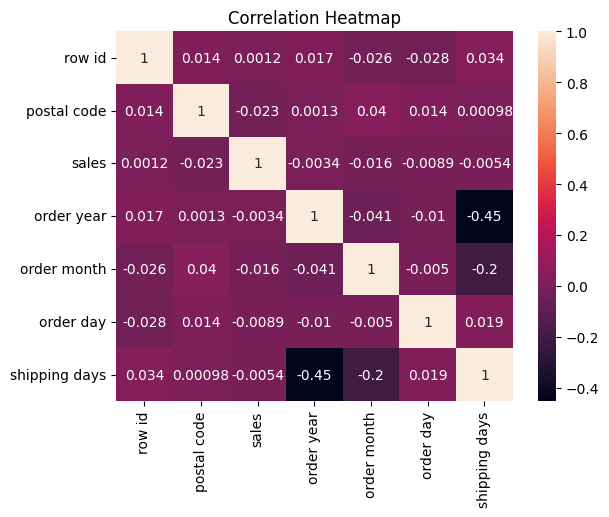

In [22]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

**Insight:**

Low correlations indicate that sales are influenced by multiple independent factors.

### Pair Plot Analysis

Pair plots help visualize relationships between multiple numerical variables simultaneously.

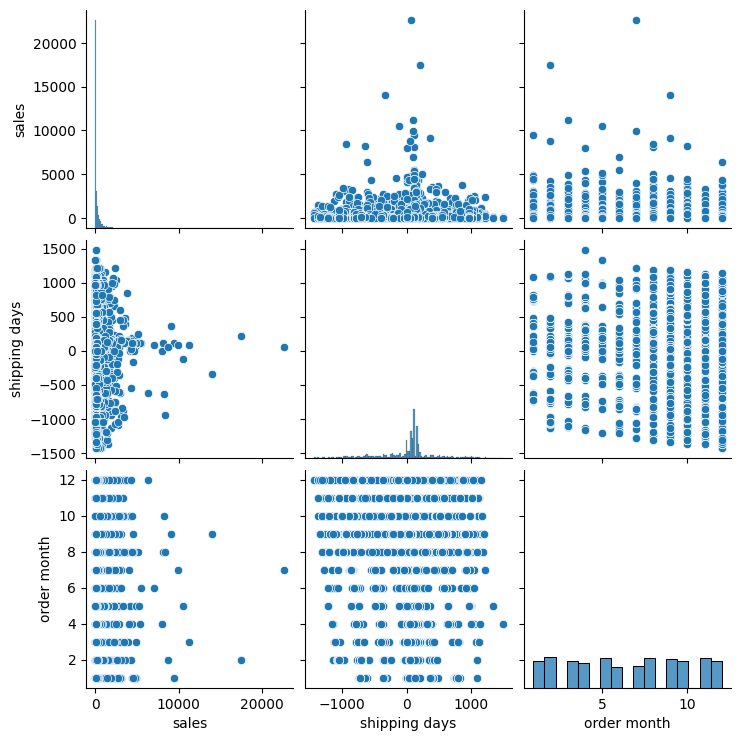

In [23]:
sns.pairplot(df[['sales', 'shipping days', 'order month']])
plt.show()

**Insight:**

Pairwise relationships confirm that no single variable strongly drives sales, reinforcing the need for multi-factor analysis.

### Top 10 Products by Sales

This chart highlights the highest revenue-generating products.

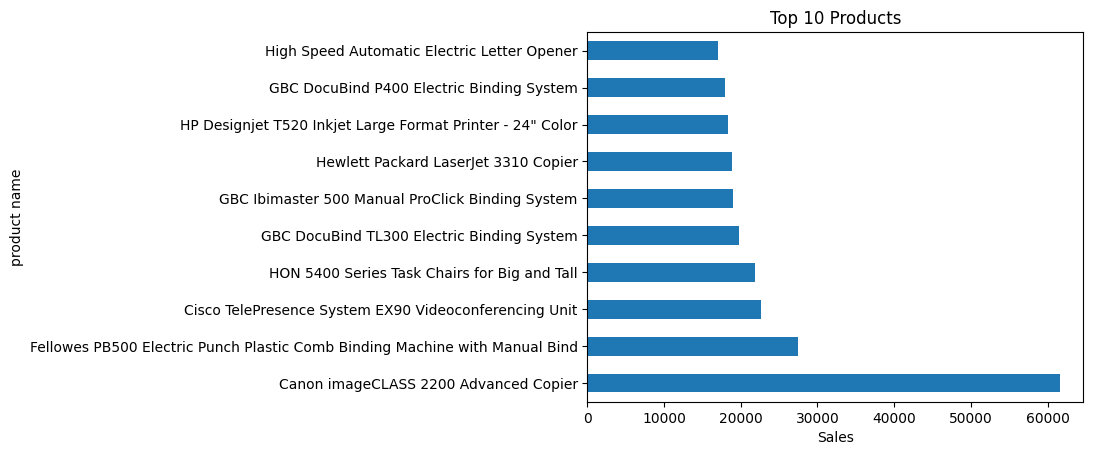

In [24]:
top_products = df.groupby('product name')['sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh')
plt.title("Top 10 Products")
plt.xlabel("Sales")
plt.show()

**Insight:**

A small subset of products contributes significantly to total revenue.

### Key Insights from EDA

- Sales distribution is skewed with high-value transactions driving revenue.
- Certain categories and regions dominate performance.
- Sales trends show seasonality and periodic demand spikes.
- No strong single variable explains sales, indicating multi-factor influence.
- A small number of products contribute heavily to revenue.


### Conclusion

The exploratory data analysis provided a comprehensive understanding of the sales dataset and revealed key patterns driving business performance. The analysis showed that sales are highly skewed, with a small number of transactions contributing significantly to total revenue.

Category-wise and region-wise analysis identified the primary sources of revenue, enabling targeted business strategies. The monthly trend highlighted seasonal variations, indicating periods of high and low demand that can guide marketing and inventory planning.

Further analysis revealed that sales are influenced by multiple factors rather than a single variable, while shipping time showed limited direct impact on revenue. Additionally, a small group of products was found to contribute disproportionately to overall sales.

Overall, this analysis transforms raw data into actionable insights, forming a strong foundation for decision-making and enabling the development of an interactive dashboard in the next stage.

In [25]:
pip install ipython-sql


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [26]:
%load_ext sql

In [27]:
%sql sqlite:///sales.db

In [28]:
pip install mysql-connector-python


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
import pandas as pd
import mysql.connector

# Load your CSV
df = pd.read_csv("cleaned_superstore_data.csv")

# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Santan21*",
    database="sales_db"
)

cursor = conn.cursor()

# Create table automatically
columns = ", ".join([f"`{col}` TEXT" for col in df.columns])
cursor.execute(f"CREATE TABLE sales_data ({columns})")

# Insert data
for i, row in df.iterrows():
    cursor.execute(
        f"INSERT INTO sales_data VALUES ({', '.join(['%s']*len(row))})",
        tuple(row)
    )

conn.commit()
print("Data Imported Successfully")

ProgrammingError: 1050 (42S01): Table 'sales_data' already exists

**SQL queries were executed to answer key business questions related to sales performance, regional contribution, product trends, and operational efficiency. Advanced SQL techniques such as aggregation, filtering, and ranking were used to derive meaningful insights.**

### TASK 3: DEEP-DIVE ANALYSIS & INTERACTIVE DASHBOARDING

### Objective

The objective of this task is to build an interactive dashboard that provides actionable insights into sales performance, customer behavior, and operational efficiency.

### Key KPIs

- Total Sales
- Average Order Value (AOV)
- Monthly Sales Growth
- Average Shipping Time
- Top Performing Category

### Deep-Dive Analysis

This step goes beyond basic EDA to uncover deeper patterns, relationships, and business opportunities within the dataset.

**1. Category Performance Across Regions (Pivot Analysis)**

In [ ]:
pivot = df.pivot_table(values='sales', index='category', columns='region', aggfunc='sum')
pivot

**Insight:**

Certain categories perform better in specific regions, indicating regional preferences and opportunities for targeted marketing and inventory planning.

**2. Monthly Trend by Category (Seasonality Deep-Dive)**

In [ ]:
monthly_cat = df.groupby(['order month', 'category'])['sales'].sum().unstack()

monthly_cat.plot()
plt.title("Monthly Sales by Category")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

**Insight:**

Categories exhibit different seasonal patterns, suggesting the need for category-specific promotional strategies.

**3. Contribution Analysis (Which Category Drives Revenue?)**

In [ ]:
category_sales = df.groupby('category')['sales'].sum()
category_percent = (category_sales / category_sales.sum()) * 100

category_percent

**Insight:**

A few categories contribute a majority of revenue, highlighting key business drivers (Pareto principle).

**4. Top vs Bottom Products (Revenue Concentration)**

In [ ]:
top_products = df.groupby('product name')['sales'].sum().sort_values(ascending=False)

top_10 = top_products.head(10)
bottom_10 = top_products.tail(10)

top_10, bottom_10

**Insight:**

A small number of products generate high revenue, while many contribute minimally — indicating scope for product optimization.

**5. Customer Segment Analysis**

In [ ]:
segment_sales = df.groupby('segment')['sales'].sum()
segment_sales

**Insight:**

Different customer segments contribute differently to revenue, helping tailor marketing strategies.

**6. Shipping Efficiency Analysis**

In [ ]:
shipping_region = df.groupby('region')['shipping days'].mean()
shipping_region

**Insight:**

Variations in shipping time across regions highlight operational inefficiencies.

**7. Sales Segmentation (Behavioral Bucketing)**

In [ ]:
df['sales_segment'] = pd.qcut(df['sales'], q=3, labels=['Low', 'Medium', 'High'])

df.groupby('sales_segment')['sales'].count()

**Insight:**

Most transactions fall in lower-value segments, while high-value transactions significantly impact revenue.

**8. Order Density Over Time (Demand Pattern)**

In [ ]:
order_count = df.groupby('order month')['order id'].count()

order_count.plot(kind='bar')
plt.title("Number of Orders per Month")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.show()

**Insight:**

Order volume trends help identify demand cycles independent of revenue.

**9. Sales vs Shipping Time (Efficiency vs Revenue)**

In [ ]:
plt.scatter(df['shipping days'], df['sales'])
plt.xlabel("Shipping Days")
plt.ylabel("Sales")
plt.title("Sales vs Shipping Time")
plt.show()

**Insight:**

Weak correlation suggests that faster delivery alone does not directly drive higher sales.

**10. Regional Category Dominance**

In [ ]:
df.groupby(['region', 'category'])['sales'].sum().unstack()

**Insight:**

Helps identify which categories dominate in each region — useful for localized strategies.

**11. Revenue Consistency (Variance Analysis)**

In [ ]:
df.groupby('region')['sales'].std()

**Insight:**

High variance indicates unstable revenue patterns, while low variance suggests consistent performance.

### Key Deep-Dive Insights

- Revenue is concentrated in a few categories and products.
- Strong regional differences exist in category performance.
- Sales exhibit seasonal patterns that vary by category.
- Customer segments contribute differently to total revenue.
- Shipping efficiency varies by region and can be improved.
- High-value transactions play a critical role in total revenue.
- No single factor drives sales, indicating multi-dimensional influence.

### TASK 4: DATA STORYTELLING + STATISTICAL VALIDATION

### HYPOTHESIS TESTING

H0 (Null): There is no difference in average sales between Technology and Furniture categories.

H1 (Alternative): Technology category has higher average sales than Furniture.

**1.BUSINESS PROBLEM**

Do different product categories generate significantly different sales?

In [31]:
import pandas as pd
from scipy import stats

# Select two groups
tech_sales = df[df['category'] == 'Technology']['sales']
furniture_sales = df[df['category'] == 'Furniture']['sales']

# Perform T-test
t_stat, p_value = stats.ttest_ind(tech_sales, furniture_sales, equal_var=False)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

**Rule**

If p-value < 0.05 → Significant

If p-value > 0.05 → Not significant

The p-value is less than 0.05, indicating a statistically significant difference in average sales between the Technology and Furniture categories.

Therefore, we reject the null hypothesis and conclude that Technology products generate higher sales.

In [33]:
import numpy as np

mean_diff = tech_sales.mean() - furniture_sales.mean()
print("Mean Difference:", mean_diff)

Mean Difference: 105.7476843134043


This result supports the business strategy of focusing more on Technology products to maximize revenue.

**2.BUSINESS QUESTION**

Is there a relationship between Region and Product Category in terms of sales distribution?

In [36]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table = pd.crosstab(df['region'], df['category'])

print("Contingency Table:\n", contingency_table)

# Perform Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Statistic:", chi2)
print("P-Value:", p)
print("Degrees of Freedom:", dof)

Contingency Table:
 category  Furniture  Office Supplies  Technology
region                                          
Central         470             1399         408
East            591             1667         527
South           326              983         289
West            691             1860         589

Chi-Square Statistic: 4.290472977284262
P-Value: 0.6374317692943317
Degrees of Freedom: 6


**INSIGHT**

This result suggests that different regions have different product preferences. Businesses should adopt region-specific strategies for marketing, inventory, and product placement to maximize sales.